In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Confirm dataset path
dataset_path = 'creditcard.csv'
df = pd.read_csv(dataset_path)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# lets take a look at basic information
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())

print('\nMissing values per column:')
print(df.isnull().sum())

df.describe().T

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


Class counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Class distribution (%):
Class
0    99.827251
1     0.172749
Name: count, dtype: float64


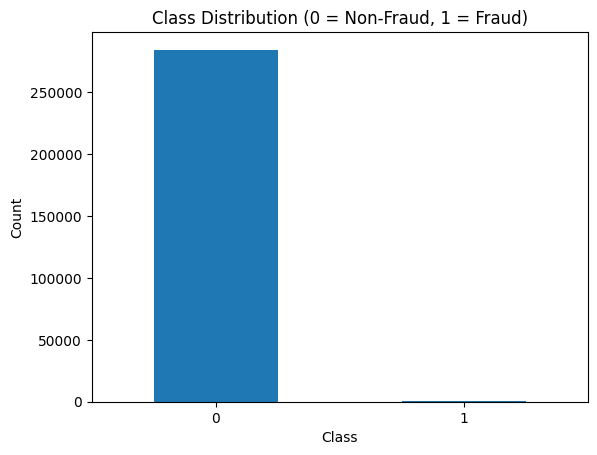

In [7]:
# see how much of the data is fraud vs not fraud
class_counts = df['Class'].value_counts()
print('Class counts:\n', class_counts)
print('\nClass distribution (%):')
print(class_counts / len(df) * 100)

plt.figure()
class_counts.plot(kind='bar')
plt.xticks(rotation=0)
plt.title('Class Distribution (0 = Non‑Fraud, 1 = Fraud)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [8]:
# Data Preprocessing
# Convert Time (seconds) to hour of the day (0-23)
df['Hour'] = (df['Time'] / 3600) % 24

# Drop raw Time column
df = df.drop('Time', axis=1)

df[['Hour', 'Class']].head()



,Hour,Class
0,0.000000,0
1,0.000000,0
2,0.000278,0
3,0.000278,0
4,0.000556,0


Scale the Amount column

Amount is not scaled while V1–V28 are already PCA-scaled.
We scale Amount and create Amount_Scaled so the model treats it properly.

In [9]:
from sklearn.preprocessing import StandardScaler, RobustScaler

scaler_amount = StandardScaler()
df['Amount_Scaled'] = scaler_amount.fit_transform(df[['Amount']])

# Drop raw Amount column
df = df.drop('Amount', axis=1)

df.head()


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Hour,Amount_Scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.000000,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,0.000000,-0.342475
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,0.000278,1.160686
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.000278,0.140534
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.000556,-0.073403


Split Train/Test

In [10]:
from sklearn.model_selection import train_test_split

# Define features and label
X = df.drop('Class', axis=1)
y = df['Class']

# Stratified split preserves fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((227845, 30), (56962, 30))

First Baseline Model

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Logistic Regression baseline
log_reg = Pipeline(steps=[
    ('scaler', StandardScaler()),  # scales all features together
    ('clf', LogisticRegression(max_iter=2000))
])

log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:,1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


Confusion Matrix:
 [[56851    13]
 [   35    63]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9595894034316034


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score
)

from sklearn.ensemble import RandomForestClassifier

from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [13]:
#new scaler
scaler = RobustScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

for col in ['Time', 'Amount']:
    if col in X_train_scaled.columns:
        X_train_scaled[col] = scaler.fit_transform(X_train[[col]])
        X_test_scaled[col] = scaler.transform(X_test[[col]])

In [14]:
def evaluate_model(y_true, y_prob, threshold=0.5, verbose=True):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)

    if verbose:
        print('Confusion Matrix:')
        print(cm)
        print('\nClassification Report:')
        print(classification_report(y_true, y_pred, digits=4))
        print(f'ROC-AUC: {roc_auc:.4f}')
        print(f'PR-AUC:  {pr_auc:.4f}')
        print(f'F1-score (threshold={threshold}): {f1:.4f}')

    return {
        'confusion_matrix': cm,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'f1': f1,
        'threshold': threshold
    }


def plot_roc_pr_curves(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    prec, rec, _ = precision_recall_curve(y_true, y_prob)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.show()

    plt.figure()
    plt.plot(rec, prec)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.show()

Confusion Matrix:
[[54876  1988]
 [    8    90]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.9650    0.9821     56864
           1     0.0433    0.9184    0.0827        98

    accuracy                         0.9650     56962
   macro avg     0.5216    0.9417    0.5324     56962
weighted avg     0.9982    0.9650    0.9806     56962

ROC-AUC: 0.9773
PR-AUC:  0.6906
F1-score (threshold=0.5): 0.0827


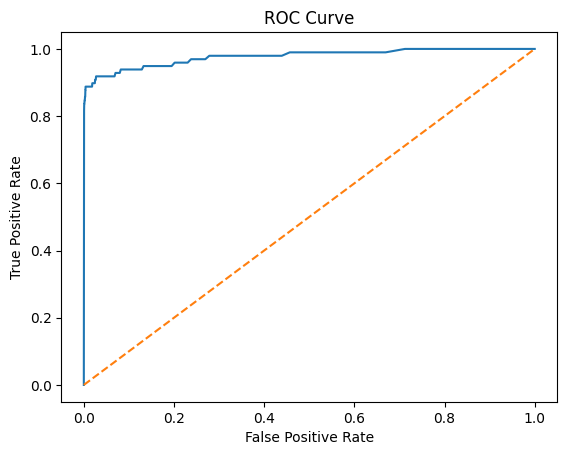

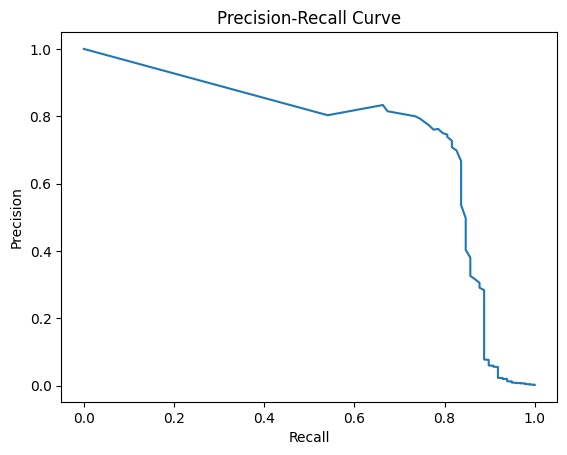

In [15]:
# random undersampling + random forest
undersample_rf = Pipeline(steps=[
    ('undersample', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
])

undersample_rf.fit(X_train_scaled, y_train)
y_test_prob_rf = undersample_rf.predict_proba(X_test_scaled)[:, 1]

rf_results = evaluate_model(y_test, y_test_prob_rf, threshold=0.5)
plot_roc_pr_curves(y_test, y_test_prob_rf)

## 2. XGBoost

In [16]:
from xgboost import XGBClassifier

# Calculating scale_pos_weight for XGBoost to handle imbalance which effectively tells the model to pay more attention to the minority class
neg_count, pos_count = y_train.value_counts()
scale_pos_weight = neg_count / pos_count

# XGBoost Classifiers
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Training XGBoost...")
xgb.fit(X_train_scaled, y_train)
y_test_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print("Evaluating XGBoost...")
xgb_results = evaluate_model(y_test, y_test_prob_xgb, threshold=0.5)

Training XGBoost...
Evaluating XGBoost...
Confusion Matrix:
[[56853    11]
 [   16    82]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9998     56864
           1     0.8817    0.8367    0.8586        98

    accuracy                         0.9995     56962
   macro avg     0.9407    0.9183    0.9292     56962
weighted avg     0.9995    0.9995    0.9995     56962

ROC-AUC: 0.9659
PR-AUC:  0.8755
F1-score (threshold=0.5): 0.8586


Baseline ROC-AUC: 0.9596
XGBoost  ROC-AUC: 0.9659
ROC-AUC Improvement: 0.0063


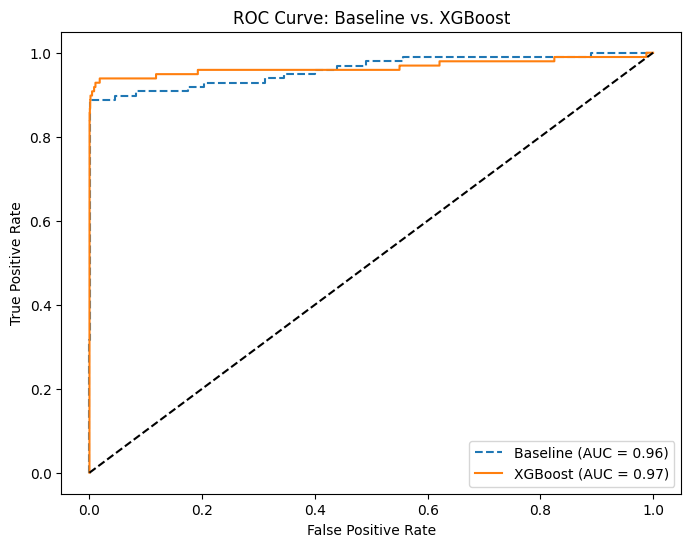

In [17]:
# Comparing XGBoost with the Baseline Logistic Regression model

# Getting Baseline Metrics for comparison
baseline_prob = log_reg.predict_proba(X_test)[:, 1]
baseline_auc = roc_auc_score(y_test, baseline_prob)

print(f"Baseline ROC-AUC: {baseline_auc:.4f}")
print(f"XGBoost  ROC-AUC: {xgb_results['roc_auc']:.4f}")

print(f"ROC-AUC Improvement: {xgb_results['roc_auc'] - baseline_auc:.4f}")

# Plotting ROC Curves for both
fpr_base, tpr_base, _ = roc_curve(y_test, baseline_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_base, tpr_base, label=f'Baseline (AUC = {baseline_auc:.2f})', linestyle='--')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_results["roc_auc"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve: Baseline vs. XGBoost')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [18]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import numpy as np

if 'X_train_scaled' not in locals() or 'y_train' not in locals():
    print("Data not found. Please run the XGBoost setup cell first.")
else:
    # Recalculating scale_pos_weight
    neg_count = np.sum(y_train == 0)
    pos_count = np.sum(y_train == 1)
    scale_pos_weight = neg_count / pos_count

    # Hyperparameter
    param_grid = {
        'n_estimators': [100, 200, 300, 400],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'scale_pos_weight': [scale_pos_weight]
    }

    xgb_base = XGBClassifier(random_state=42, n_jobs=-1)

    print("Tuning XGBoost...\n")
    rs_xgb = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=param_grid,
        n_iter=15,              # Trying 15 random combinations
        scoring='roc_auc',
        cv=3,                   # 3-fold cross-validation
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    rs_xgb.fit(X_train_scaled, y_train)

    print(f"\nBest Params: {rs_xgb.best_params_}")

    # Evaluating best XGBoost
    best_xgb = rs_xgb.best_estimator_
    y_prob_best_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]

    # Calculating metrics
    best_xgb_auc = roc_auc_score(y_test, y_prob_best_xgb)
    print(f"\nTuned XGBoost ROC-AUC: {best_xgb_auc:.4f}")

    # Comparisons
    print("\n--- Comparisons ---")
    if 'baseline_auc' in locals():
        print(f"Improvement over Baseline(Logistic Regression): {best_xgb_auc - baseline_auc:.4f}")

Tuning XGBoost...

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best Params: {'subsample': 0.9, 'scale_pos_weight': np.float64(577.2868020304569), 'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Tuned XGBoost ROC-AUC: 0.9795

--- Comparisons ---
Improvement over Baseline(Logistic Regression): 0.0199


## 3. Naive Bayes Model
Attempting to beat the baseline accuracy using Gaussian Naive Bayes.

Transforming data to be more Gaussian...
Training Gaussian Naive Bayes...
Naive Bayes ROC-AUC: 0.9626
Baseline ROC-AUC:    0.9596

SUCCESS: Naive Bayes BEAT the Baseline by 0.0030!


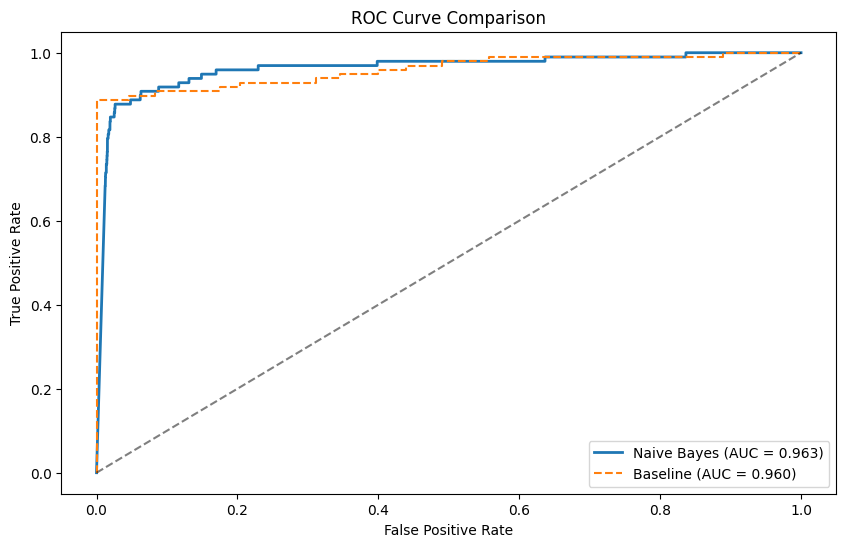

In [19]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Preprocessing using Power Transformer as Gaussian Naive Bayes works best when features are normally distributed as in bell curve.
# PowerTransformer helps converts the features to look more Gaussian.
pt = PowerTransformer(method='yeo-johnson')

print("Transforming data to be more Gaussian...")
X_train_pt = pt.fit_transform(X_train)
X_test_pt = pt.transform(X_test)

# Training Model
nb = GaussianNB()
print("Training Gaussian Naive Bayes...")
nb.fit(X_train_pt, y_train)

# Evaluating ROC-AUC score
y_prob_nb = nb.predict_proba(X_test_pt)[:, 1]
nb_roc_auc = roc_auc_score(y_test, y_prob_nb)

print(f"Naive Bayes ROC-AUC: {nb_roc_auc:.4f}")

# Comparing this model with Baseline model
if 'log_reg' in locals():
    # Recalculating baseline score
    y_prob_base = log_reg.predict_proba(X_test)[:, 1]
    base_roc_auc = roc_auc_score(y_test, y_prob_base)

    print(f"Baseline ROC-AUC:    {base_roc_auc:.4f}")

    improvement = nb_roc_auc - base_roc_auc
    if improvement > 0:
        print(f"\nSUCCESS: Naive Bayes BEAT the Baseline by {improvement:.4f}!")
    else:
        print(f"\nResult: Naive Bayes did not beat the Baseline (Difference: {improvement:.4f})")

    # Plotting ROC Comparison
    fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
    fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)

    plt.figure(figsize=(10, 6))
    plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {nb_roc_auc:.3f})', linewidth=2)
    plt.plot(fpr_base, tpr_base, label=f'Baseline (AUC = {base_roc_auc:.3f})', linestyle='--')
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.title('ROC Curve Comparison')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()

else:
    print(f"Baseline model not in memory. Target to beat was ~0.9596.")

In [20]:
from sklearn.model_selection import GridSearchCV
import numpy as np

# Hyperparameter Tuning
# Tuning 'var_smoothing'which helps if the Gaussian assumption isn't perfect.

if 'X_train_pt' not in locals():
    print("Transformed data not found. Please run the previous Naive Bayes cell first.")
else:
    params = {'var_smoothing': np.logspace(0, -9, num=100)}

    print("Tuning Naive Bayes...")
    gs_nb = GridSearchCV(
        estimator=GaussianNB(),
        param_grid=params,
        cv=5,             # 5-fold cross-validation
        scoring='roc_auc',
        n_jobs=-1
    )

    gs_nb.fit(X_train_pt, y_train)

    print(f"Best var_smoothing: {gs_nb.best_params_['var_smoothing']:.2e}")

    # Evaluating Best Model
    best_nb = gs_nb.best_estimator_
    y_prob_tuned = best_nb.predict_proba(X_test_pt)[:, 1]
    tuned_roc_auc = roc_auc_score(y_test, y_prob_tuned)

    print(f"Tuned Naive Bayes ROC-AUC: {tuned_roc_auc:.4f}")

    # Comparisions with previous NB and Baseline(Logistic reasoning)
    if 'nb_roc_auc' in locals():
        print(f"Improvement over Default NB: {tuned_roc_auc - nb_roc_auc:.4f}")

    if 'base_roc_auc' in locals():
        print(f"Improvement over Baseline:   {tuned_roc_auc - base_roc_auc:.4f}")

Tuning Naive Bayes...
Best var_smoothing: 1.00e+00
Tuned Naive Bayes ROC-AUC: 0.9678
Improvement over Default NB: 0.0052
Improvement over Baseline:   0.0082


C:\Users\Sukhm\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best params: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': None}
Best PR-AUC (cv): 0.8440260838080335
Confusion Matrix:
[[56851    13]
 [   18    80]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9997     56864
           1     0.8602    0.8163    0.8377        98

    accuracy                         0.9995     56962
   macro avg     0.9299    0.9080    0.9187     56962
weighted avg     0.9994    0.9995    0.9994     56962

ROC-AUC: 0.9831
PR-AUC:  0.8734
F1-score (threshold=0.5): 0.8377


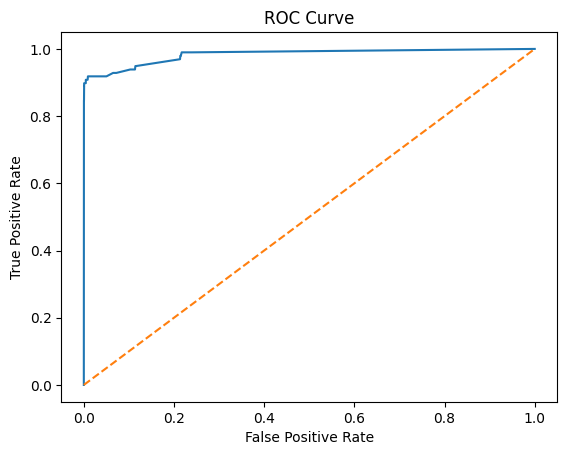

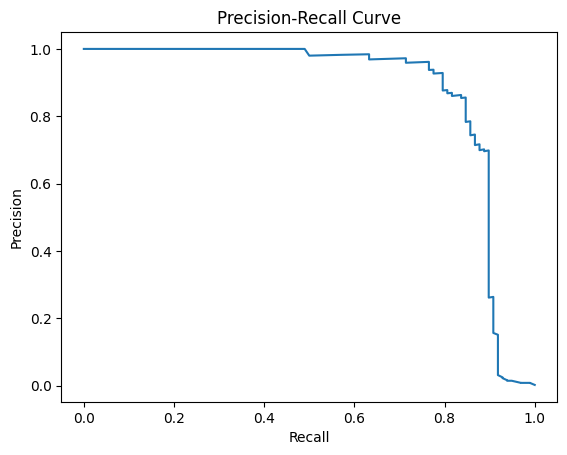

In [22]:
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE

param_dist = {
    'model__n_estimators': [200],
    'model__max_depth': [None],
    'model__min_samples_split': [5],
    'model__min_samples_leaf': [1]
}

rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
pipe = Pipeline(steps=[('smote', SMOTE(random_state=RANDOM_STATE)), ('model', rf)])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=10,
    scoring='average_precision',
    n_jobs=-1,
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE
)

search.fit(X_train_scaled, y_train)

print('Best params:', search.best_params_)
print('Best PR-AUC (cv):', search.best_score_)

best_pipe = search.best_estimator_
y_test_prob_rf_tuned = best_pipe.predict_proba(X_test_scaled)[:, 1]

rf_tuned_results = evaluate_model(y_test, y_test_prob_rf_tuned, threshold=0.5)
plot_roc_pr_curves(y_test, y_test_prob_rf_tuned)